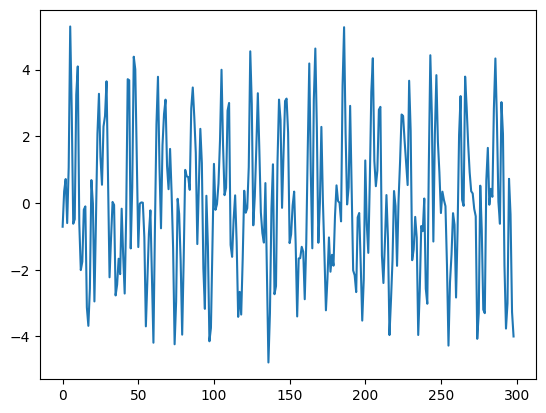

In [152]:
import numpy as np
import csv
import matplotlib.pyplot as plt

data = []
with open('array.csv', mode ='r')as file:
  csvFile = csv.reader(file)
  for lines in csvFile:
        data.append(float(lines[0]))

plt.plot(data[1:300])

1.0593575327019227
2.8559910332609473
0.3147911980168907


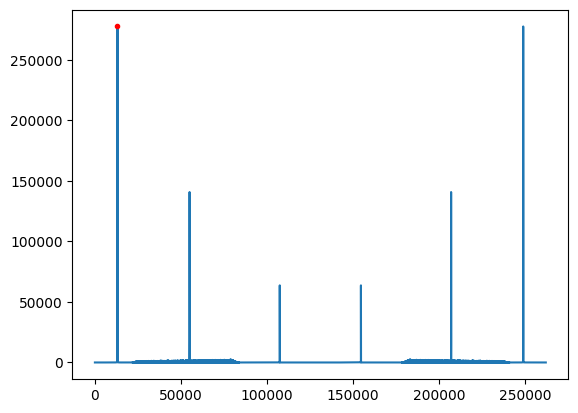

In [156]:
data_fft = np.fft.fft(data)
spectrum = np.abs(data_fft)
plt.plot(spectrum)
ix_peak = np.argmax(spectrum[0:int(len(spectrum)/2)])
plt.plot(ix_peak, spectrum[ix_peak], 'r.')
ahat = spectrum[ix_peak]/len(data)
phihat = -np.angle(data_fft[ix_peak]) #? Negative?
omegahat = (ix_peak)/len(data)*2.0*np.pi
print(ahat)
print(phihat)
print(omegahat)

0.043239082967425416


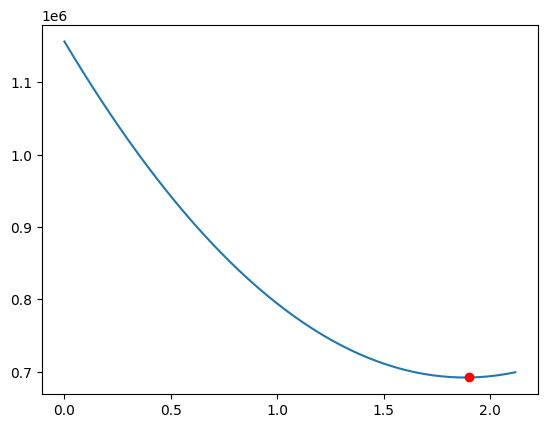

In [157]:
error = []
a_range = np.linspace(0,2*ahat)
for a_to_use in a_range:
    error.append(loss_function(data,a_to_use,omegahat,phihat))
plt.plot(a_range, error)
ix_ahat = np.argmin(error)
plt.plot(a_range[ix_ahat], error[ix_ahat], 'ro')
print(a_range[ix])

-3.0133643820146996


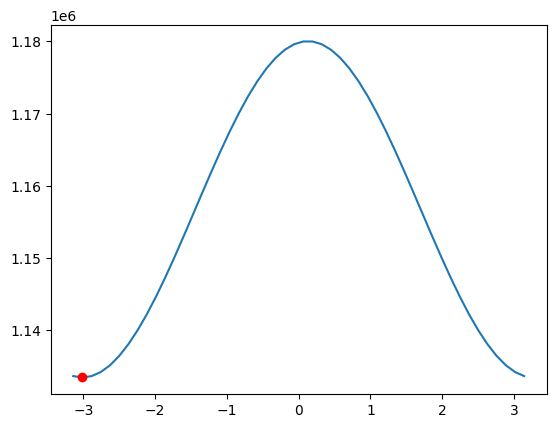

In [92]:
phi_error = []
phi_range = np.linspace(-np.pi, np.pi)
for phi_to_use in phi_range:
    phi_error.append(loss_function(data,a_range[ix],omegahat,phi_to_use))
plt.plot(phi_range, phi_error)
ix_phi = np.argmin(phi_error)
plt.plot(phi_range[ix_phi], phi_error[ix_phi], 'ro')
phihat = phi_range[ix_phi]
print(phi_range[ix_phi])

1.9025196505667183
0.3147911980168907


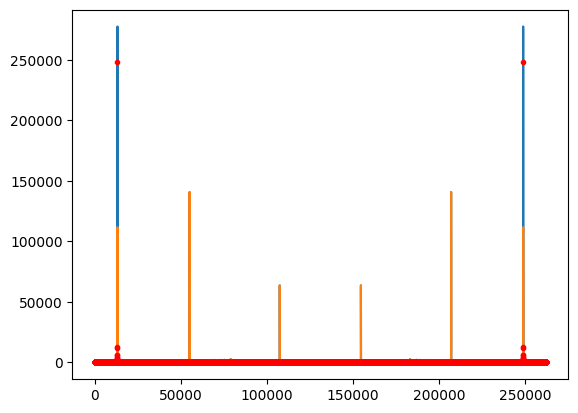

In [158]:
signal = signal_model(data, a_range[ix_ahat], omegahat, phihat)
print(a_range[ix_ahat])
error = data - signal
print(omegahat)
plt.plot(np.abs(np.fft.fft(data)))
plt.plot(np.abs(np.fft.fft(error)))
plt.plot(np.abs(np.fft.fft(signal)),'r.')

In [163]:
import numpy as np
from scipy.optimize import least_squares

class cosine_optimize:

    def __init__(self, data, ahat = 1, omegahat = np.pi/4, phihat = np.pi/4):
        self.phi = phihat
        self.omega = omegahat
        self.a = ahat
        self.data = data

    def loss_function(self, a,omega,phi):
        t = np.linspace(0,len(self.data),len(self.data))
        return np.sum(np.square((self.signal_model(a,omega,phi)-self.data)))
    
    def signal_model(self, a,omega,phi):
        t = np.linspace(0,len(self.data),len(self.data))
        return a*np.cos(omega*t+phi)
        
    def single_variable_loss_function_phi(self, phi_in):
        return self.loss_function(ahat,omegahat,phi_in)
    
    def single_variable_loss_function_omega(self, omega_in):
        return self.loss_function(ahat,omega_in,phihat)
    
    def single_variable_loss_function_a(self, ahat_in):
        return self.loss_function(ahat_in,omegahat,phihat)

    def optimize_one_step(self, ahat, omegahat, phihat):
        omega_opt = least_squares(self.single_variable_loss_function_omega, omegahat)    
        phi_opt = least_squares(self.single_variable_loss_function_phi,  phihat)    
        a_opt = least_squares(self.single_variable_loss_function_a, ahat)

        self.phi = phi_opt.x
        self.omega = omega_opt.x
        self.a = a_opt.x

    def multi_step(self):
        for k in range(10):
            self.optimize_one_step(self.a, self.omega, self.phi)


optimizer = cosine_optimize(data, ahat, omegahat, phihat)

optimizer.multi_step()
optimizer.multi_step()
optimizer.multi_step()

print(optimizer.a)
print(optimizer.omega)
print(optimizer.phi)
            

[1.88332846]
[0.31479233]
[3.26980009]


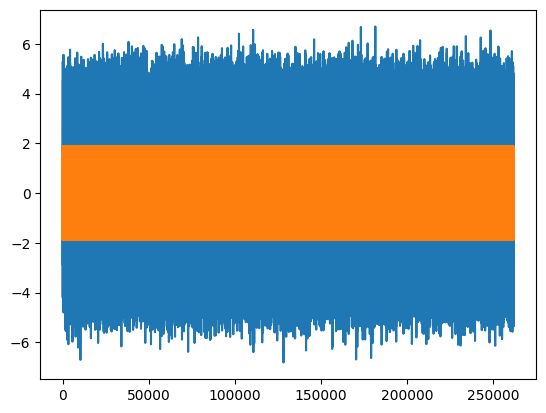

In [160]:
plt.plot(data)
plt.plot(signal_model(data, optimizer.a, optimizer.omega, optimizer.phi))

1.9025196505667183
0.3147911980168907


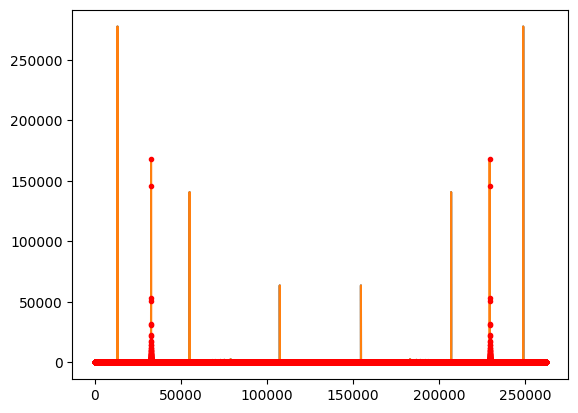

In [162]:
signal = signal_model(data, optimizer.a, optimizer.omega, optimizer.phi)
print(a_range[ix_ahat])
error = data - signal
print(omegahat)
plt.plot(np.abs(np.fft.fft(data)))
plt.plot(np.abs(np.fft.fft(error)))
plt.plot(np.abs(np.fft.fft(signal)),'r.')

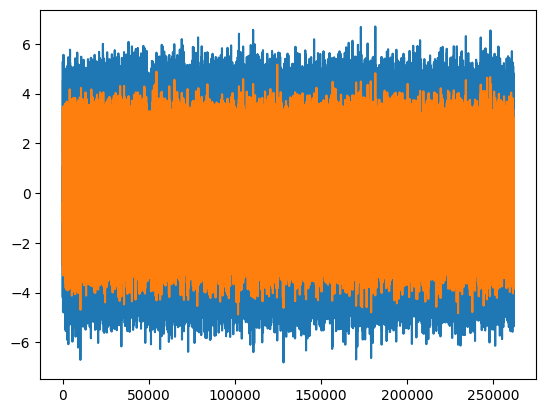

In [141]:
plt.plot(data)
plt.plot(error)
